<a href="https://colab.research.google.com/github/kamalidoss/Python-Social-Media-Engagement-Analysis/blob/main/Social_Media_Engagement_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Social Media Engagement Analytics Using Python***

In [ ]:
#importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re

***❖ Task 1 — Data Import & Setup***

In [ ]:
#Loading the Dataset

url=('https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/refs/heads/main/social_media_engagement_5000.csv')
df=pd.read_csv(url)

In [ ]:
#To view the data:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
#Check Data Types
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
#Convert Date Columns to DateTime

df['posted_at']= pd.to_datetime(df['posted_at'],errors='coerce')

/tmp/ipykernel_8155/999067355.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at']= pd.to_datetime(df['posted_at'],errors='coerce')


In [ ]:
df['age'] = df['age'].fillna(df['age'].median()).astype(int)

*Task 1 completed successfully. Data imported from github and loaded. Converted needed dtypes.*

***❖ Task 2 — Data Cleaning***

In [ ]:
#Verify Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate
count,5000.000000,5000.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348
std,26090.370121,14.687151,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,NaN,230927.884535,5.318029


In [ ]:
#Imputing categorical columns using most repeating values

df['gender'].fillna(df['gender'].mode()[0],inplace=True)
df['sentiment'].fillna(df['sentiment'].mode()[0],inplace=True)

/tmp/ipykernel_8155/3205702011.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(df['gender'].mode()[0],inplace=True)
/tmp/ipykernel_8155/3205702011.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
#Group based imputation for neumerical columns

df['likes'] = df.groupby('post_type')['likes'].transform(lambda x: x.fillna(x.median()))
df['shares'] = df.groupby('post_type')['likes'].transform(lambda x: x.fillna(x.median()))
df['comments'] = df.groupby('post_type')['likes'].transform(lambda x: x.fillna(x.median()))

df['age'] = df.groupby('gender')['age'].transform(lambda x: x.fillna(x.median()))

In [ ]:
#Verify Information after Imputation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

*Ensured there is no null values after imputation. Hence proceeding with next step.*

In [ ]:
#Identify Duplicate Values
df.duplicated().sum()

np.int64(0)

In [ ]:
#Examined the unique values in categorical columns

cols = ['gender','country','post_type','post_category',
        'is_verified','device_type','sentiment']

for col in cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in gender:
['Female' 'Male' 'Other']

Unique values in country:
['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']

Unique values in post_type:
['image' 'reel' 'text' 'video']

Unique values in post_category:
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']

Unique values in is_verified:
[False  True]

Unique values in device_type:
['mobile' 'tablet' 'desktop']

Unique values in sentiment:
['negative' 'positive' 'neutral']


*Standardizing categorical variables ensures uniformity and prevents duplication of categories during analysis. Checked the values are already in standard format. Proceeding with next step.*

In [ ]:
#Extract and create hashtags count column

df['hashtag_count'] = df['hashtags'].apply(
    lambda x: len(re.findall(r"#\w+", str(x))))

In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011.0,7011.0,7011.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750.0,11750.0,11750.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862.0,4862.0,4862.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350.0,5350.0,5350.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682.0,12682.0,12682.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


*A new feature hashtag_count was created by extracting the number of hashtags from the hashtags column. Feature engineering like hashtag count helps uncover patterns between content richness and engagement. Task 2 completed successfully.*

***❖ Task 3 — Data Exploration using Pandas***

In [ ]:
#1. View Dataset Structure

print(df.head())      # First 5 rows
print(df.tail())      # Last 5 rows
print(df.shape)       # (rows, columns)
print(df.columns)     # Column names

   user_id  age  gender country  post_id post_type post_category    likes  \
0    25795   43  Female  Brazil   496713     image       fitness   7011.0   
1    10860   33    Male  Brazil   157326      reel          food  11750.0   
2    86820   32  Female      UK   109864      text          food   4862.0   
3    64886   51   Other  France   848877      text       fitness   5350.0   
4    16265   34   Other      UK   449706     image       fitness  12682.0   

   comments   shares  watch_time_sec  impression_count  posted_at  \
0    7011.0   7011.0            5726             44650 2022-12-17   
1   11750.0  11750.0            5947             80216 2023-06-02   
2    4862.0   4862.0            6946             44858 2023-05-07   
3    5350.0   5350.0             229             70455 2023-02-12   
4   12682.0  12682.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      mobile 

In [ ]:
#2. Check Data Types & Info

print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
#3. Summary Statistics
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.379800,10106.379800,10106.379800,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,10.000000,10.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,5235.000000,5235.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10057.500000,10057.500000,10057.500000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,14959.000000,14959.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,19998.000000,19998.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.322279,5702.322279,5702.322279,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [ ]:
#4. Categorical Analysis

print(df['post_type'].value_counts())
print(df['country'].value_counts())
print(df['sentiment'].value_counts())

post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


In [ ]:
#5. Correlation Matrix

corr = df.corr(numeric_only=True)
corr

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025776,0.025776,0.025776,-0.016847,0.015326,0.010124,0.004058,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036386,-0.036386,-0.036386,0.005542,0.013322,-0.024894,-0.000079,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014613,0.014613,0.014613,0.018374,-0.007709,-0.002844,0.025208,0.010139,0.007344
likes,0.025776,-0.036386,0.014613,1.000000,1.000000,1.000000,0.008758,0.007912,-0.022972,-0.016160,0.093536,-0.002170
comments,0.025776,-0.036386,0.014613,1.000000,1.000000,1.000000,0.008758,0.007912,-0.022972,-0.016160,0.093536,-0.002170
shares,0.025776,-0.036386,0.014613,1.000000,1.000000,1.000000,0.008758,0.007912,-0.022972,-0.016160,0.093536,-0.002170
watch_time_sec,-0.016847,0.005542,0.018374,0.008758,0.008758,0.008758,1.000000,-0.004335,0.002761,0.012326,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007912,0.007912,0.007912,-0.004335,1.000000,-0.015513,0.008317,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022972,-0.022972,-0.022972,0.002761,-0.015513,1.000000,-0.017808,0.002292,0.008802
is_verified,0.004058,-0.000079,0.025208,-0.016160,-0.016160,-0.016160,0.012326,0.008317,-0.017808,1.000000,0.005528,0.001396


In [ ]:
#6. GroupBy Analysis
df.groupby('post_type')[['likes','comments','shares']].mean()

,likes,comments,shares
post_type,,,
image,10107.957498,10107.957498,10107.957498
reel,10033.523383,10033.523383,10033.523383
text,10097.109639,10097.109639,10097.109639
video,10190.501224,10190.501224,10190.501224


In [ ]:
#Avg Likes by Post Type
df.groupby('post_type')['likes'].mean()

,likes
post_type,
image,10107.957498
reel,10033.523383
text,10097.109639
video,10190.501224


In [ ]:
#Avg Impressions by Country
df.groupby('country')['impression_count'].mean()

,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


*Video posts tend to receive higher average likes compared to other post types. India,France,UK shows higher average impressions, indicating stronger audience engagement*

*The exploratory data analysis (Task 3) has been completed, providing key insights into the dataset. The analysis will now proceed to the next stage.*

***❖ Task 4 — Data Wrangling***

*1. Merge / Concat / Join*

*No additional datasets were provided, so merging,concat or joining was not required.*

In [ ]:
#2. Create New Fields
#Engagement_Score

df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

In [ ]:
#Log Transformation

df['log_likes'] = np.log1p(df['likes'])
df['log_impressions'] = np.log1p(df['impression_count'])

In [ ]:
#GroupBy Metrics
df.groupby('post_type')[['likes','comments','shares','engagement_score']].mean()

,likes,comments,shares,engagement_score
post_type,,,,
image,10107.957498,10107.957498,10107.957498,30323.872494
reel,10033.523383,10033.523383,10033.523383,30100.570148
text,10097.109639,10097.109639,10097.109639,30291.328916
video,10190.501224,10190.501224,10190.501224,30571.503673


*A new feature engagement_score was created by combining likes, comments, and shares.Log transformation was applied to reduce skewness in numerical features.GroupBy operations were performed to summarize post_type by likes,shares,comments,engagement_score*

***❖ Task 5 — Statistical Analysis***

In [ ]:
#1.a.Measure of Central Tendency

cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']
Summary_Table = pd.DataFrame({
     'Mean':df[cols].mean(),
     'Median':df[cols].median(),
     'Mode':df[cols].mode().iloc[0]})

# Round to 2 decimal places
Summary_Table = Summary_Table.round(2)

#Display the table
print('Measure of Central Tendency:\n',Summary_Table)

Measure of Central Tendency:
                       Mean     Median       Mode
likes             10106.38   10057.50    9983.50
comments          10106.38   10057.50    9983.50
shares            10106.38   10057.50    9983.50
watch_time_sec     4014.50    4034.50     916.00
engagement_rate       0.96       0.25       0.01
follower_count   393698.22  388982.00  497502.00


*Visualization of Central Tendency*

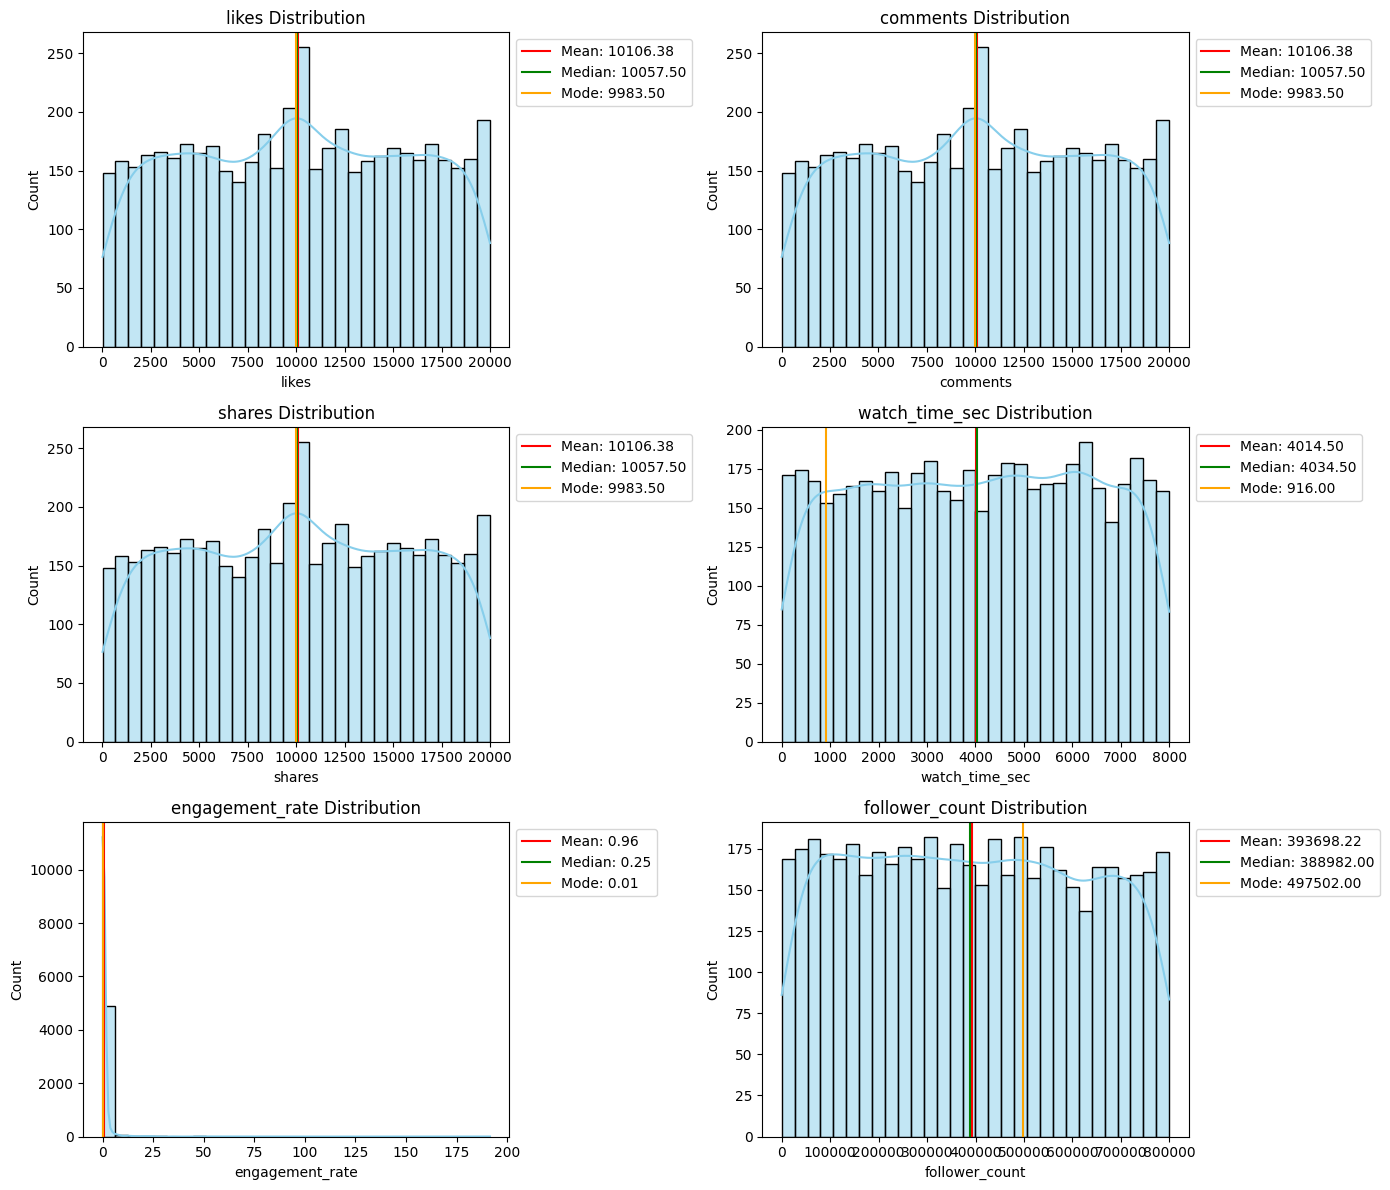

In [ ]:
#1.b.Visualization of Central Tendency

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols):

    mean_val = Summary_Table.loc[col, 'Mean']
    median_val = Summary_Table.loc[col, 'Median']
    mode_val = Summary_Table.loc[col, 'Mode']

    sns.histplot(df[col], kde=True, bins=30, color='skyblue', ax=axes[i])

    axes[i].axvline(mean_val, color='red', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', label=f'Median: {median_val:.2f}')
    axes[i].axvline(mode_val, color='orange', label=f'Mode: {mode_val:.2f}')

    axes[i].set_title(f'{col} Distribution')

    # Legend outside each plot
    axes[i].legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()


*Likes, comments, and shares show similar mean, median, and mode indicating stable distribution. Watch time shows slight skewness due to lower mode value. Engagement rate is highly skewed with most values being low. Follower count shows moderate variation across users. Overall, some metrics are consistent while others are influenced by extreme values*

In [ ]:
#2.a.Measure of Variance

Variance_Table = df[cols].var().to_frame(name='Variance')

print('Measure of Dispersion: Variance\n')
print(Variance_Table)

Measure of Dispersion: Variance

                     Variance
likes            3.251648e+07
comments         3.251648e+07
shares           3.251648e+07
watch_time_sec   5.327309e+06
engagement_rate  2.828143e+01
follower_count   5.332769e+10


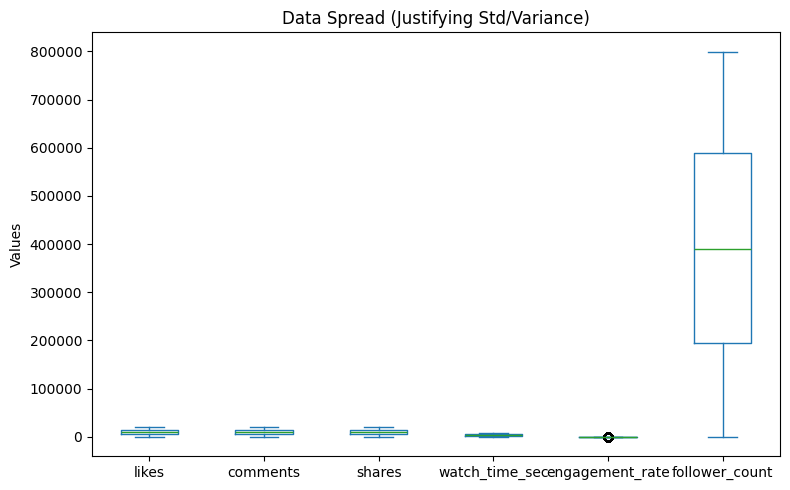

In [ ]:
#2.b.Visualization of Variance

df[cols].plot(kind='box',figsize=(8,5))
plt.title('Data Spread (Justifying Std/Variance)')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

*Box plot analysis was performed to detect outliers across all numerical features. Outliers were observed only in the engagement_rate column. However, these values were retained as they represent genuine variations in user engagement and are important for analysis. Removing them could impact the overall insights, so they were not treated as anomalies.*

In [ ]:
#3.a.Measure of Standard Deviation

Std_Dev__Table = df[cols].std().to_frame(name='Std_Dev_Table')

print('Measure of Std_Dev: Std_Dev_Table\n')
print(Std_Dev__Table)

Measure of Std_Dev: Std_Dev_Table

                 Std_Dev_Table
likes              5702.322279
comments           5702.322279
shares             5702.322279
watch_time_sec     2308.096459
engagement_rate       5.318029
follower_count   230927.884535


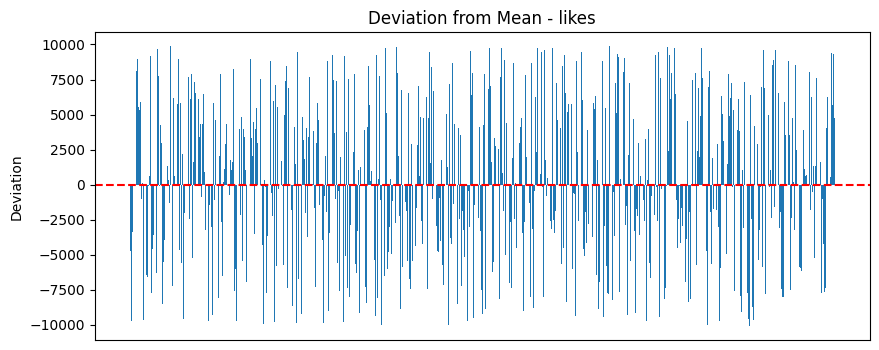

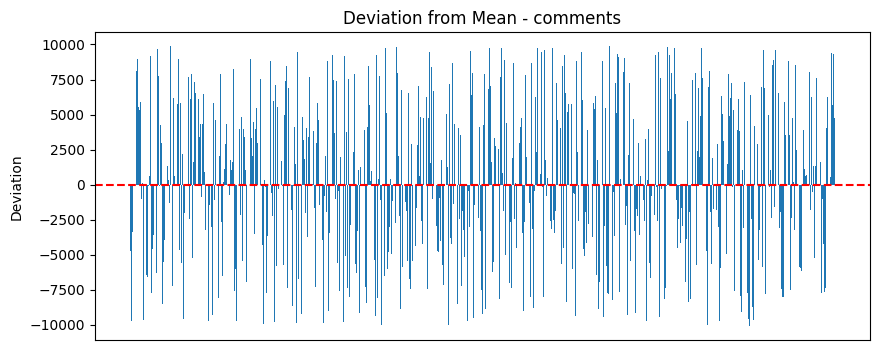

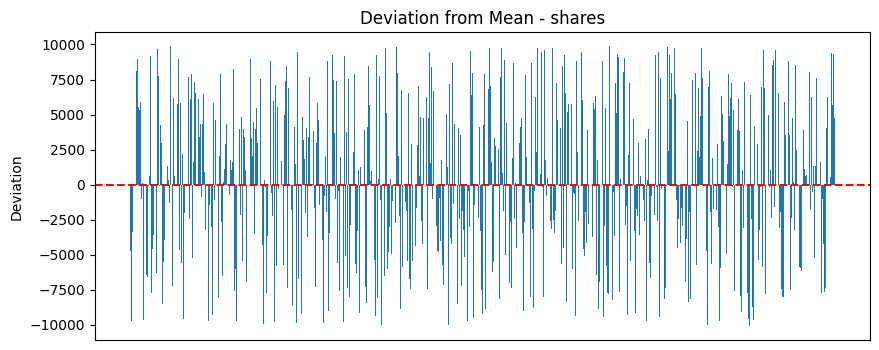

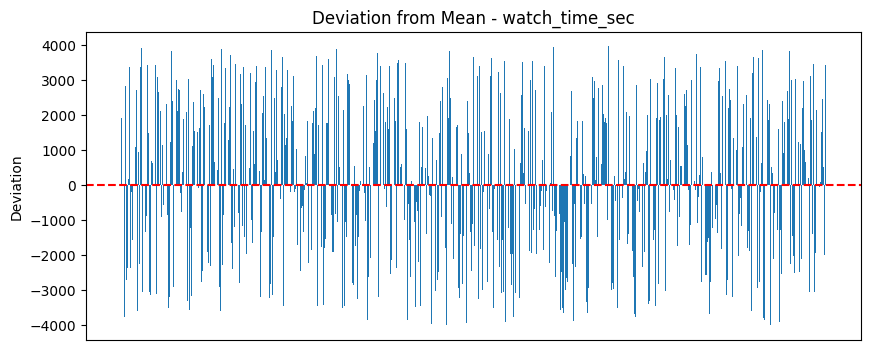

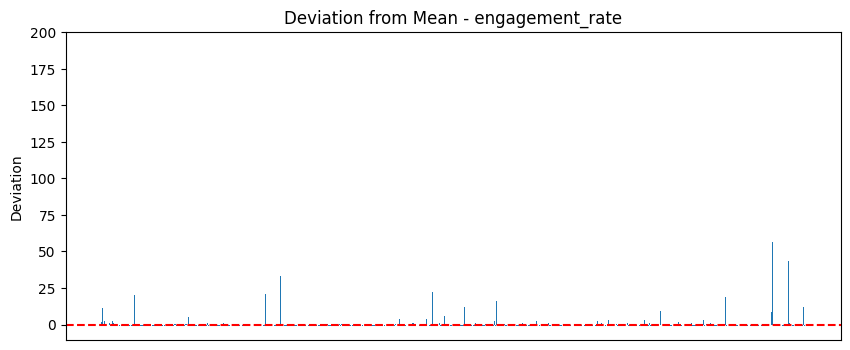

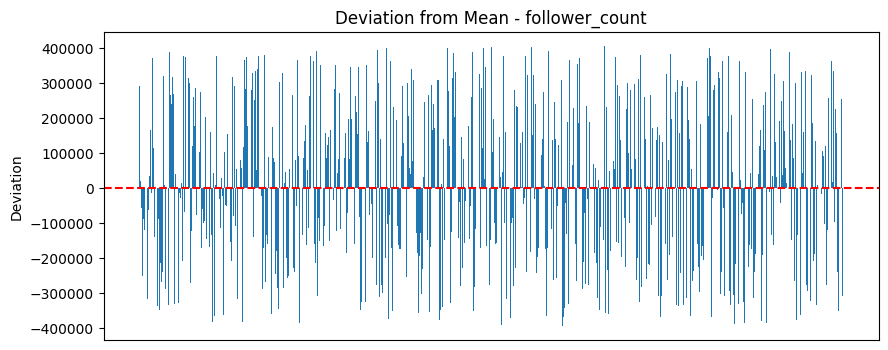

In [ ]:
#3.b.Visualization of Standard Deviation

means = df[cols].mean()
deviation = df[cols] - means

for col in cols:
  plt.figure(figsize=(10,4))
  plt.bar(range(len(deviation)),deviation[col])
  plt.axhline(0,color='red',linestyle='--')
  plt.title(f'Deviation from Mean - {col}')
  plt.ylabel('Deviation')
  plt.xticks([])
  plt.show()

*Likes, comments, and shares have equal standard deviation similar variability. Follower count shows highest variation among all features. Engagement rate is more stable with low variability. Watch time shows moderate variation. Overall, user engagement varies significantly across different metrics*

In [ ]:
#4.Measure of Percentiles

percentiles=df[cols].quantile([0.25,0.50,0.75])
percentiles

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,5235.0,5235.0,2017.75,0.145781,194480.00
0.50,10057.5,10057.5,10057.5,4034.50,0.253896,388982.00
0.75,14959.0,14959.0,14959.0,6020.25,0.504794,589744.25


In [ ]:
#5.a.Measure of Skewness

Skewness_Table=df[cols].skew().to_frame(name='Skewness')

print('Measure of Skewness: Skewness_Table\n')
print(Skewness_Table)

Measure of Skewness: Skewness_Table

                  Skewness
likes            -0.006569
comments         -0.006569
shares           -0.006569
watch_time_sec   -0.018196
engagement_rate  18.781271
follower_count    0.041118


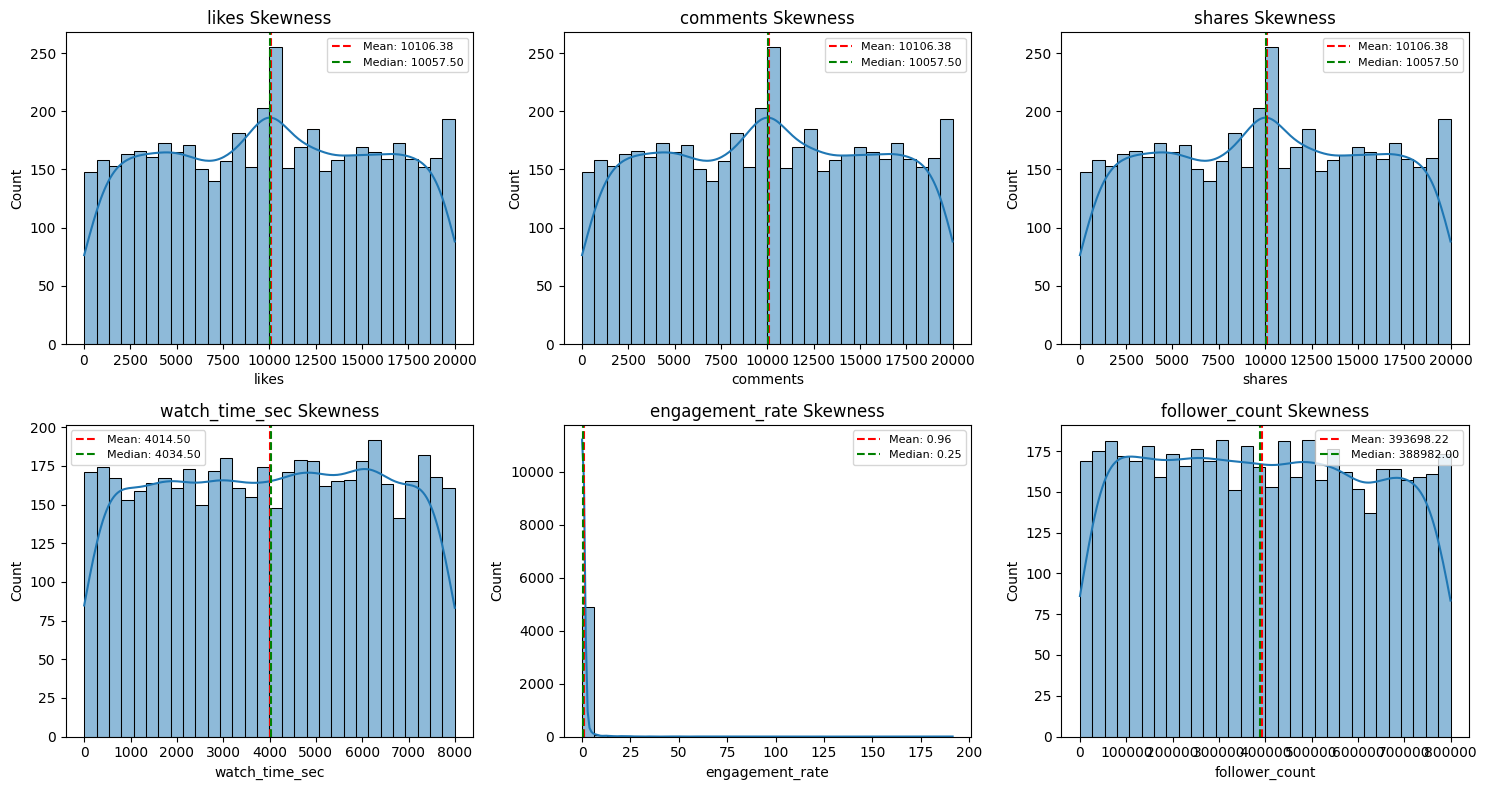

In [ ]:
#5.b.Visualization of Skewness

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):

    mean_val = df[col].mean()
    median_val = df[col].median()

    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])

    # Mean & Median lines (used to interpret skewness)
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')

    axes[i].set_title(f"{col} Skewness")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

*Likes, comments, and shares are nearly symmetric (skew ≈ 0). Watch time also shows minimal skewness. Engagement rate is highly positively skewed (extreme right skew). Follower count shows slight positive skew. Overall, engagement rate has the most uneven distribution*

In [ ]:
#6.a.Measure of Kurtosis

Kurtosis_Table=df[cols].kurt().to_frame(name='Kurtosis')

print('Measure of Kurtosis: Kurtosis_Table\n')
print(Kurtosis_Table)

Measure of Kurtosis: Kurtosis_Table

                   Kurtosis
likes             -1.150033
comments          -1.150033
shares            -1.150033
watch_time_sec    -1.195652
engagement_rate  482.991739
follower_count    -1.189474


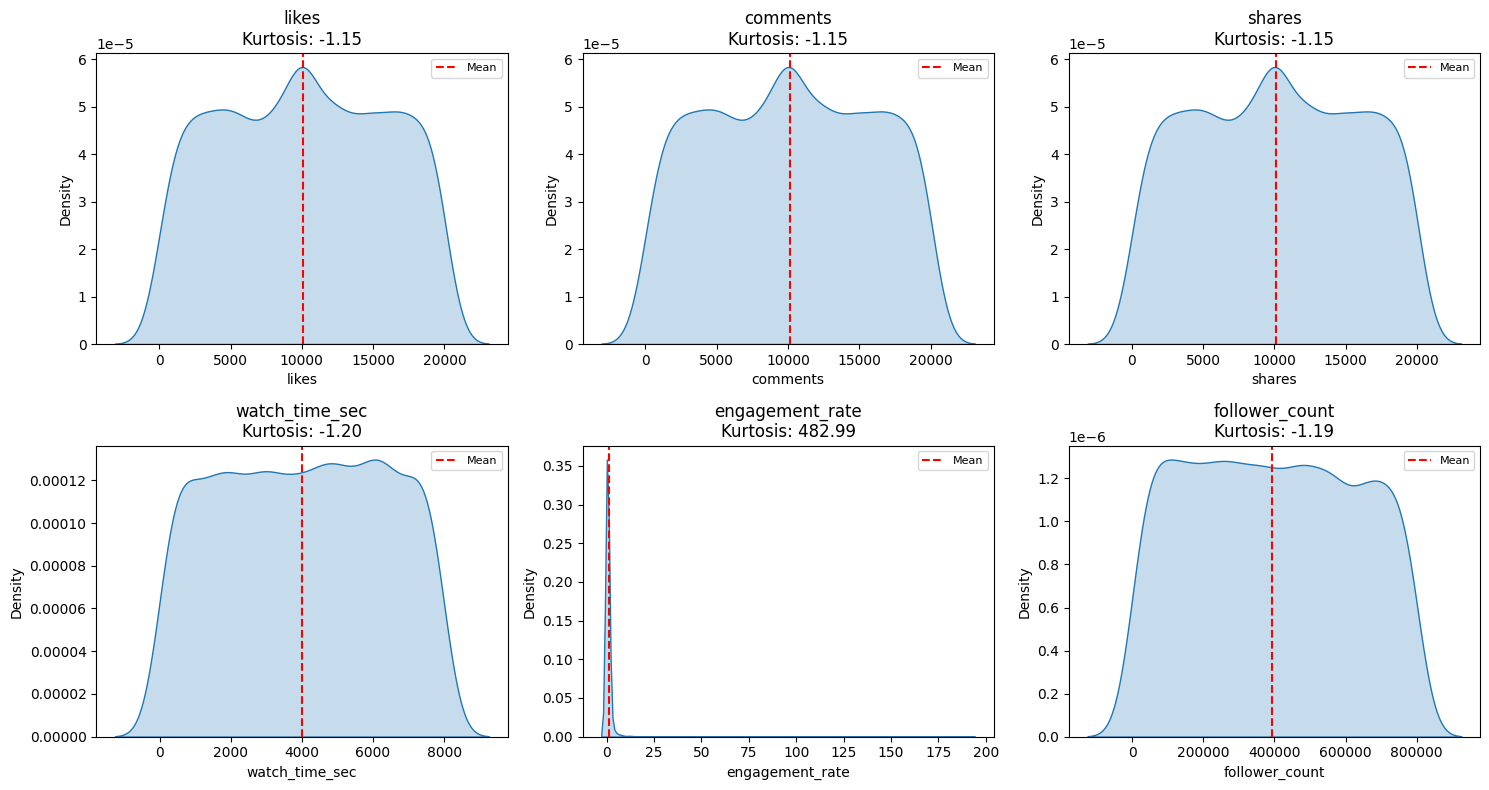

In [ ]:
#6.b.Visualization of Kurtosis

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):

    kurt_val = df[col].kurt()
    mean_val = df[col].mean()

    # KDE plot (no histogram)
    sns.kdeplot(df[col], fill=True, ax=axes[i])

    # Mean line
    axes[i].axvline(mean_val, color='red', linestyle='--', label='Mean')

    # Title with kurtosis value
    axes[i].set_title(f"{col}\nKurtosis: {kurt_val:.2f}")

    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

*Likes, comments, and shares show negative kurtosis → flat distribution. Watch time and follower count also show platykurtic behavior. Engagement rate has extremely high positive kurtosis → heavy tails & outliers. Most features have fewer extreme values. Engagement rate contains significant outliers*

*The statistical analysis (Task 5) has been completed, and the results were evaluated using both tabular and visual representations. The analysis will now proceed to the next phase.*

***❖ Task 6 — Data Visualization***

***Matplotlib***

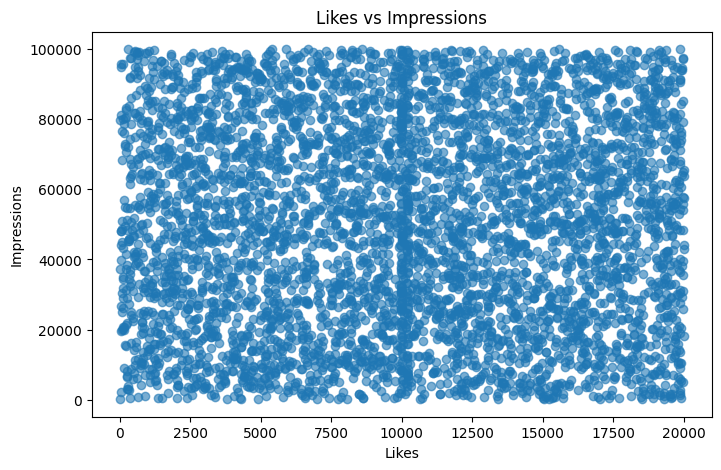

In [ ]:
#1.Scatter Plot --> likes vs impression_count by post_type

plt.figure(figsize=(8,5))

plt.scatter(df['likes'], df['impression_count'], alpha=0.6)

plt.xlabel("Likes")
plt.ylabel("Impressions")
plt.title("Likes vs Impressions")

plt.show()

*No strong correlation between likes and impressions
High impressions don’t always lead to high likes
Data is widely scattered → high variability
Possible clustering around specific like values
Engagement is inconsistent across posts*

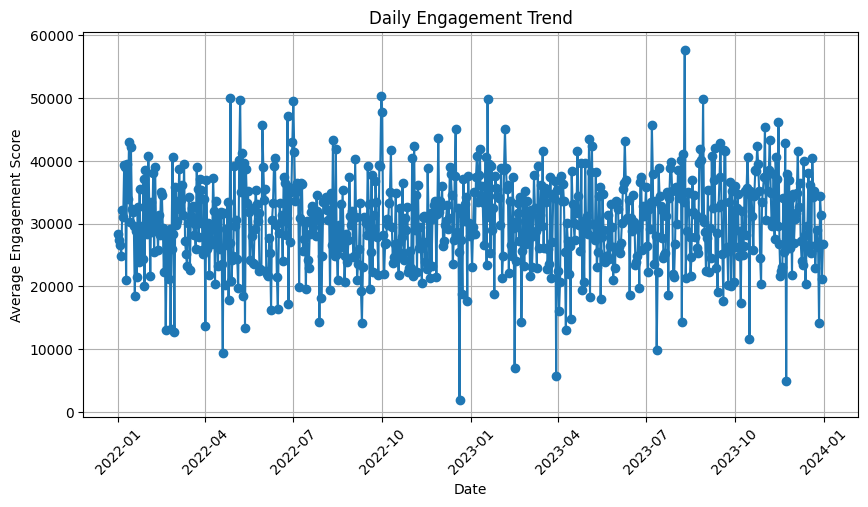

In [ ]:
#2.Daily Engagement Trend

daily_engagement = df.groupby(df['posted_at'].dt.date)['engagement_score'].mean()

plt.figure(figsize=(10,5))

plt.plot(daily_engagement.index, daily_engagement.values, marker='o')

plt.xlabel("Date")
plt.ylabel("Average Engagement Score")
plt.title("Daily Engagement Trend")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

*Engagement fluctuates over time
No consistent increasing or decreasing trend
Peaks indicate high-performing content days
Drops show low engagement periods
Overall engagement is dynamic*

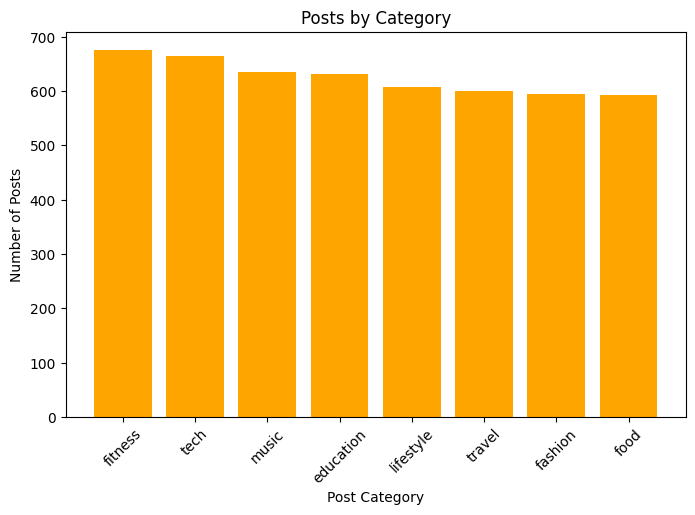

In [ ]:
#3.Bar: posts by category

category_counts = df['post_category'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(category_counts.index, category_counts.values,color='orange')

plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.title("Posts by Category")

plt.xticks(rotation=45)

plt.show()

*The distribution is quite balanced (all categories are between ~590–680), so there is no extreme drop, but fitness and tech clearly lead, indicating audience preference or posting priority in those areas.*

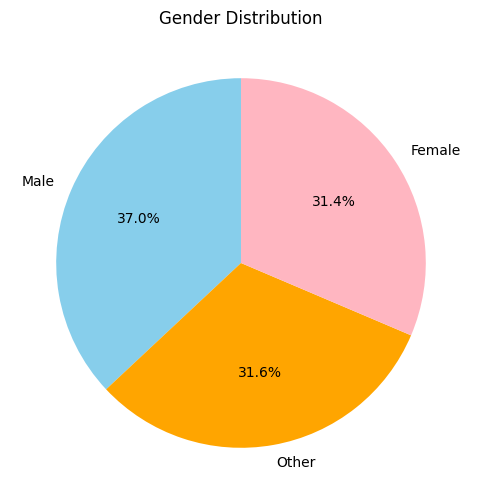

In [ ]:
#4.Pie: gender distribution

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['skyblue','orange','lightpink'])

plt.title("Gender Distribution")

plt.show()

*Male users form the largest group (37%)
Female and other categories are nearly equal (~31%)
Distribution is fairly balanced
Indicates diverse user base
No strong dominance by a single gender*

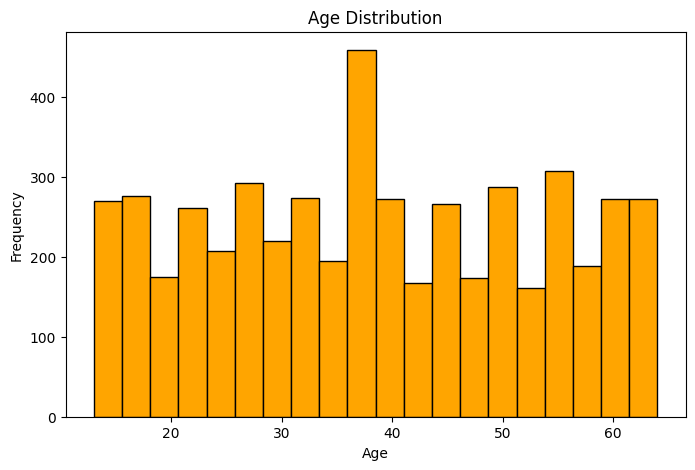

In [ ]:
#5.Histogram: age

plt.figure(figsize=(8,5))

plt.hist(df['age'].dropna(), bins=20, color= 'orange', edgecolor='black')

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

*Your audience is evenly distributed across age groups, with a small peak in the mid-age segment(30-40), which could be the most engaged demographic.*

***Seaborn***

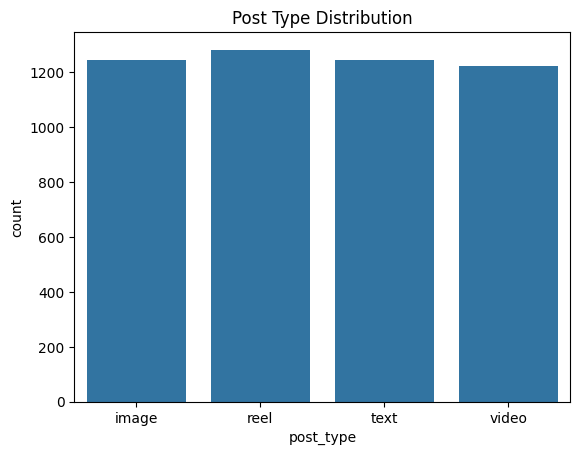

In [ ]:
#1. Count Plot — Post Type

sns.countplot(x='post_type', data=df)
plt.title("Post Type Distribution")
plt.show()

*All post types are equally distributed. However reels is even more higher.*

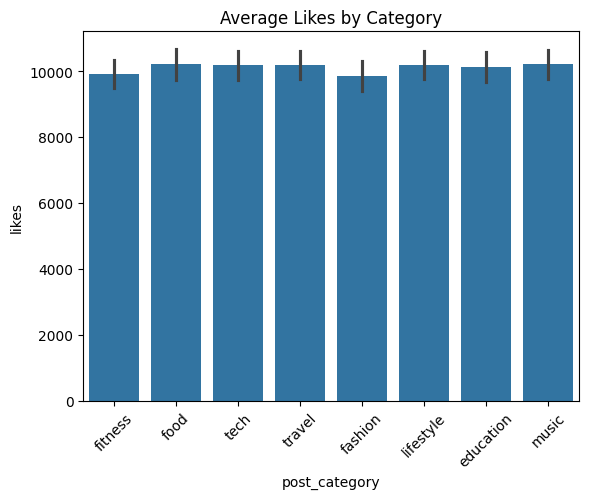

In [ ]:
#2. Bar Plot — Avg Likes by Category

sns.barplot(x='post_category', y='likes', data=df)
plt.title("Average Likes by Category")
plt.xticks(rotation=45)
plt.show()

*The likes count is evenly distributed showing that all the categories are equally liked by the followers*

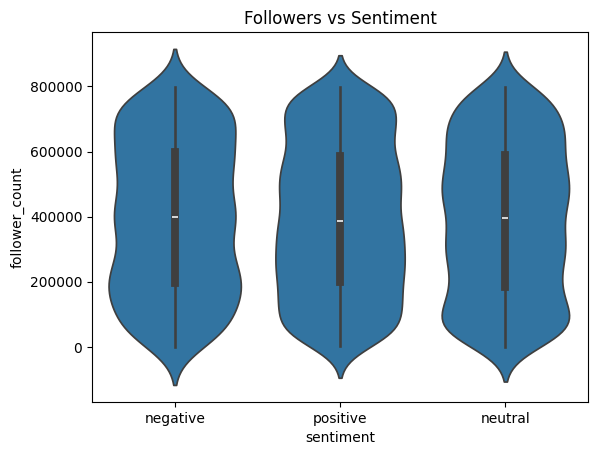

In [ ]:
#3. Violin Plot — Followers vs Sentiment

sns.violinplot(x='sentiment', y='follower_count', data=df)
plt.title("Followers vs Sentiment")
plt.show()

*There is no strong correlation between sentiment and follower count — accounts with positive, negative, or neutral sentiment have comparable audience sizes.*

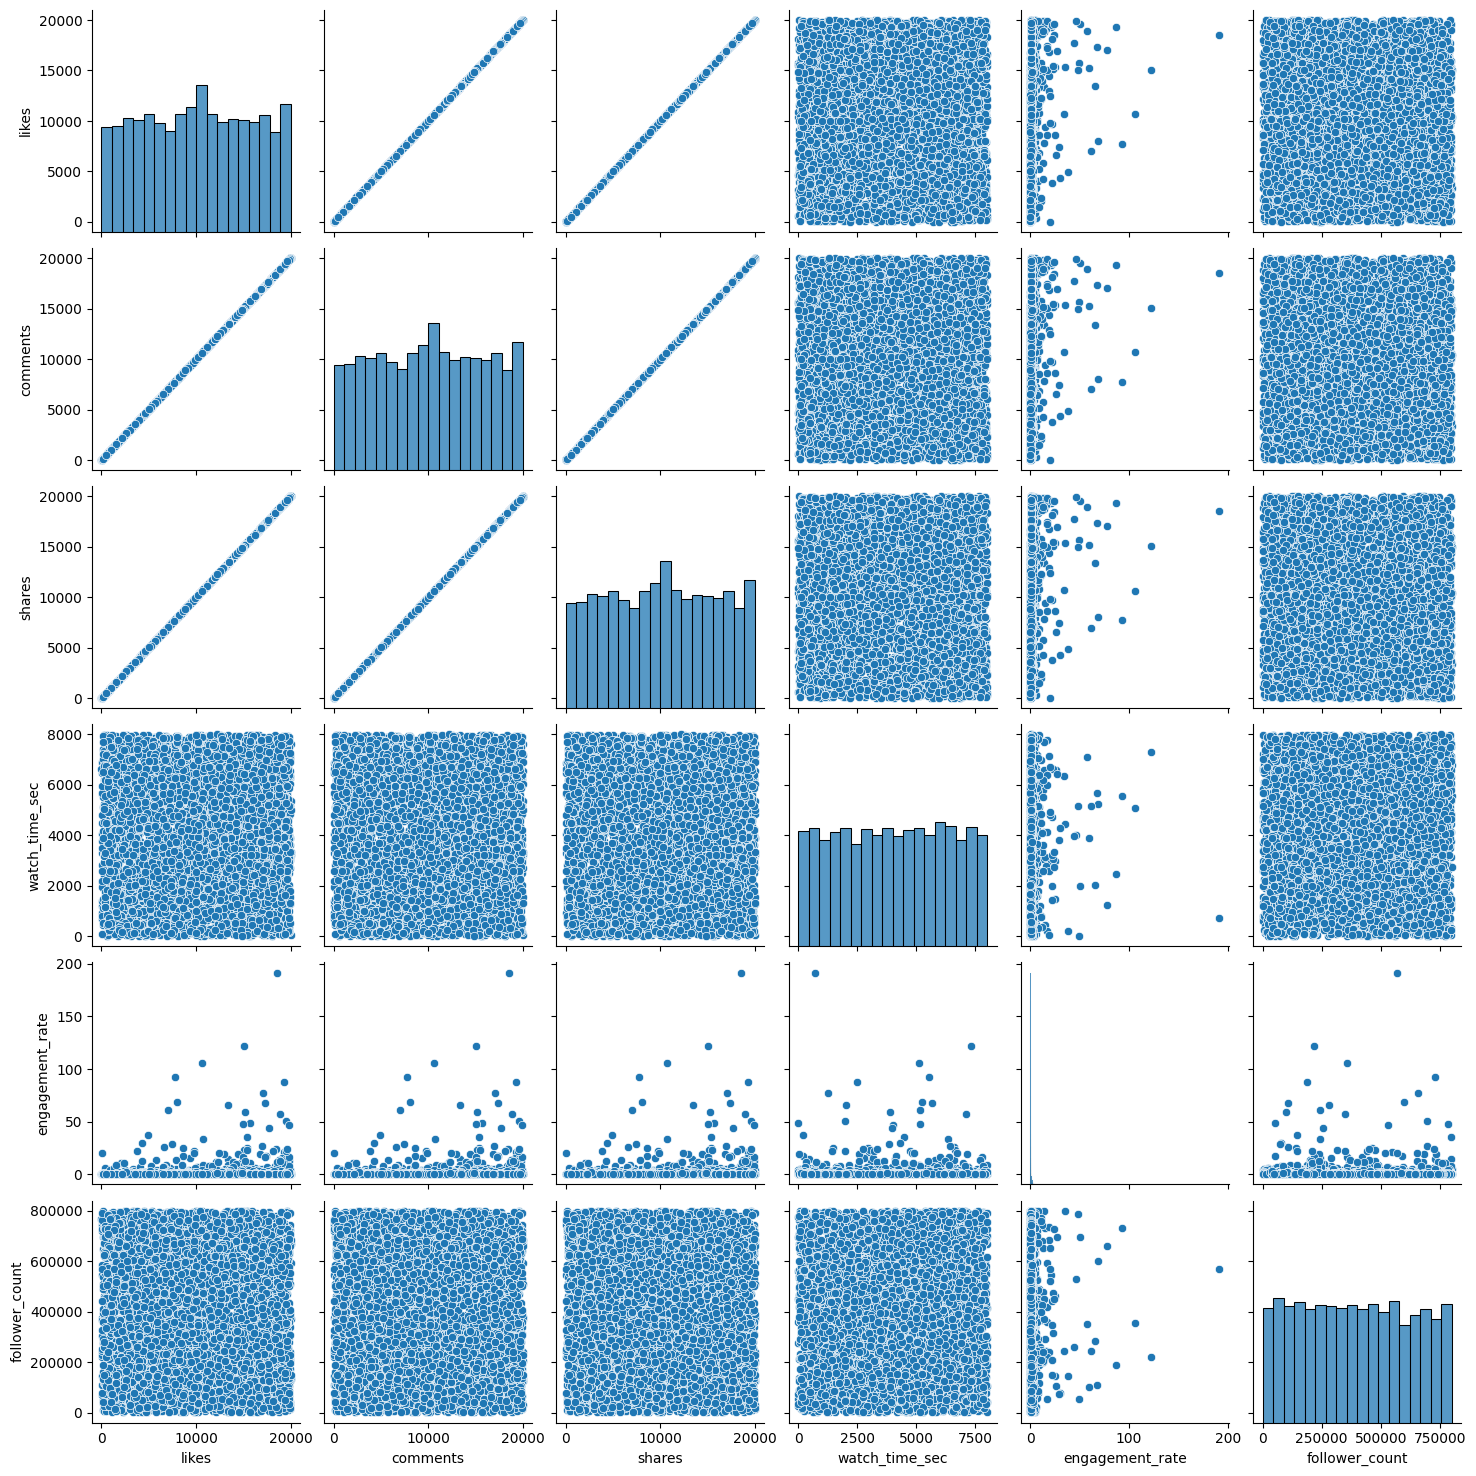

In [ ]:
#4. Pair Plot — Numeric Features
sns.pairplot(df[cols])

*Engagement metrics (likes, comments, shares) move together strongly
Follower count is not a reliable predictor of engagement
Watch time behaves independently
Engagement is driven by a few high-performing posts*

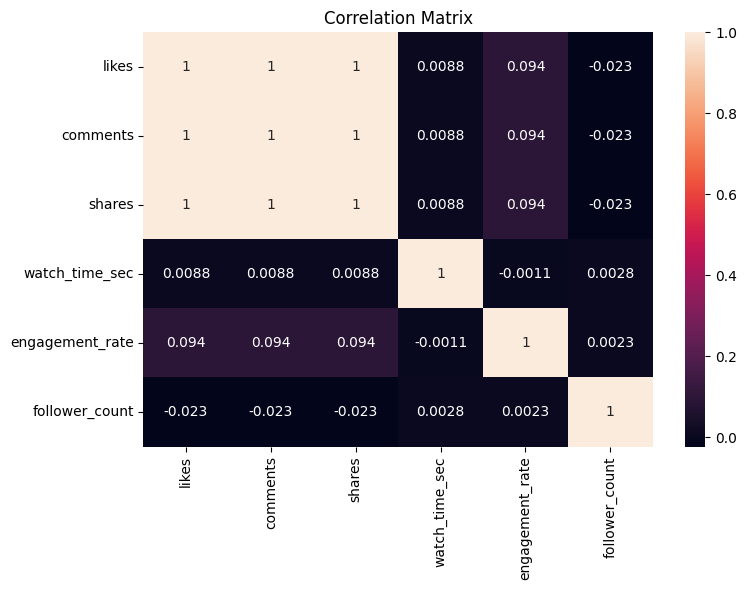

In [ ]:
#5. Heatmap — Correlation Matrix

plt.figure(figsize=(8,6))

corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

*Remove redundant variables (likes/comments/shares)
Engagement is not driven by follower count
Watch time does not translate into engagement
Most features have weak predictive power individually*

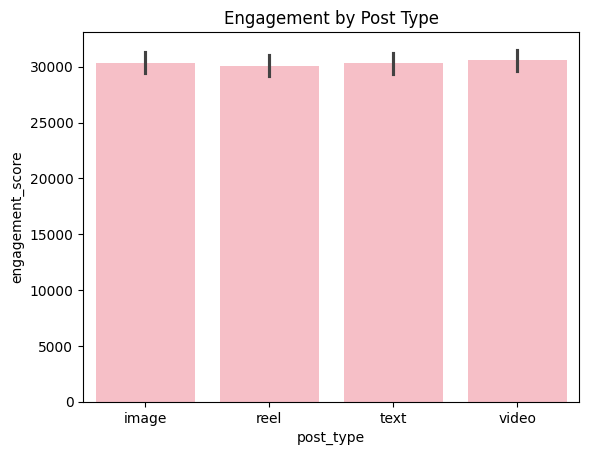

In [ ]:
#Which post types have highest engagement?

sns.barplot(x='post_type', y='engagement_score', data=df,color='lightpink')
plt.title("Engagement by Post Type")
plt.show()

*Engagement is almost identical across all post types (image, reel, text, video), around ~30K.
The overlapping error bars suggest no statistically significant difference between formats.
This indicates post type is not a strong driver of engagement in your dataset.
Engagement is likely influenced more by content quality, audience, or timing rather than format.*

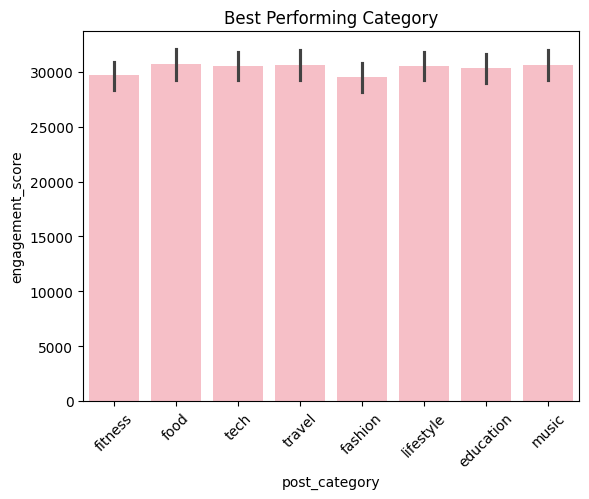

In [ ]:
#Best-performing content category

sns.barplot(x='post_category', y='engagement_score', data=df,color='lightpink')
plt.xticks(rotation=45)
plt.title("Best Performing Category")
plt.show()

*All categories show very similar engagement (~29K–32K), with no clear standout.
Slightly higher values for food, travel, lifestyle, and music, but differences are minimal.*

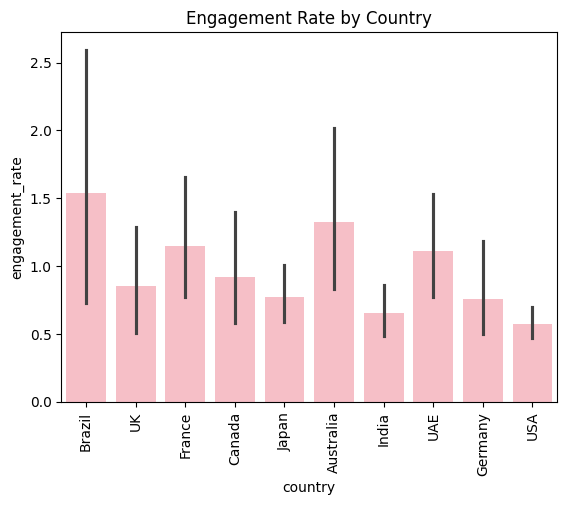

In [ ]:
#Which country has highest engagement

sns.barplot(x='country', y='engagement_rate', data=df,color='lightpink')
plt.xticks(rotation=90)
plt.title("Engagement Rate by Country")
plt.show()

*Brazil and Australia show the highest engagement rates, while USA and India are on the lower end.
There is moderate variation across countries, unlike previous charts where differences were minimal.
Large error bars (especially for Brazil) indicate high variability within countries.
Overall, location seems to have some influence on engagement, but not strongly consistent.*

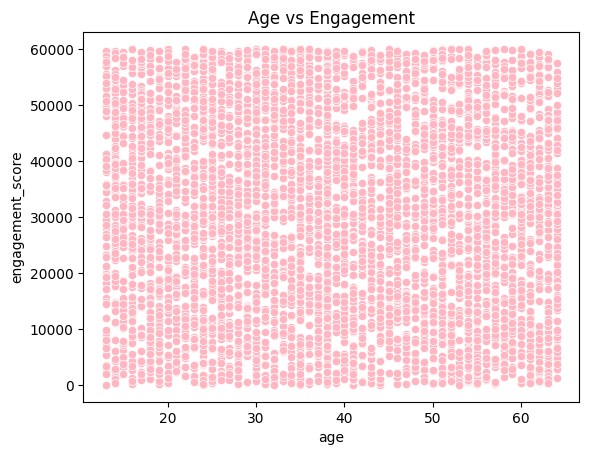

In [ ]:
#How age affects engagement

sns.scatterplot(x='age', y='engagement_score', data=df,color='lightpink')
plt.title("Age vs Engagement")
plt.show()

*Engagement levels are highly variable across all age groups, from low to very high.
No specific age group consistently outperforms others.*

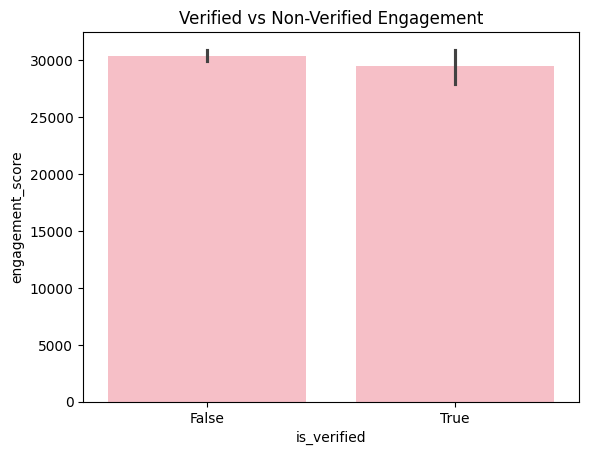

In [ ]:
#Verified vs Non-Verified Performance

sns.barplot(x='is_verified', y='engagement_score', data=df,color='lightpink')
plt.title("Verified vs Non-Verified Engagement")
plt.show()

*Non-verified users show slightly higher engagement than verified users, but the difference is very small.*

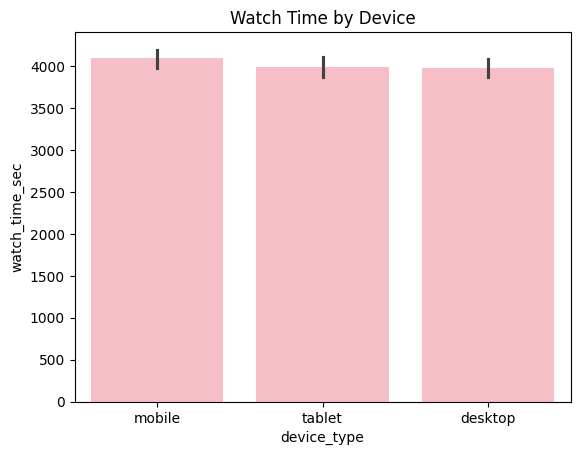

In [ ]:
#Device impact on watch time

sns.barplot(x='device_type', y='watch_time_sec', data=df,color='lightpink')
plt.title("Watch Time by Device")
plt.show()

*Mobile shows slightly higher watch time compared to tablet and desktop.
However, the differences are very small and closely clustered (~4000 sec).*

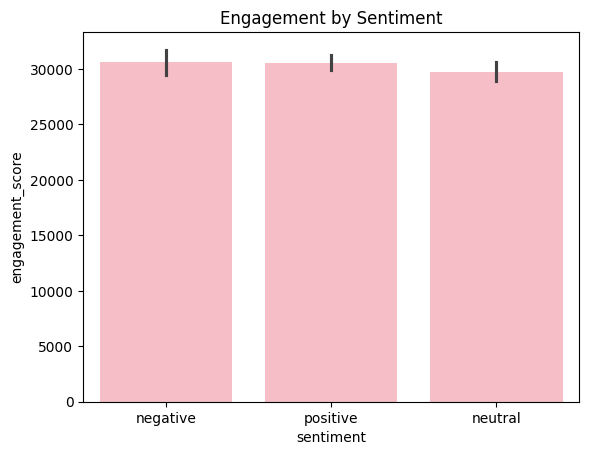

In [ ]:
#Which sentiment performs best

sns.barplot(x='sentiment', y='engagement_score', data=df,color='lightpink')
plt.title("Engagement by Sentiment")
plt.show()

*Positive and negative sentiments show slightly higher engagement than neutral posts.However, the differences are very small (~30K range) and closely clustered.*

*PLOTLY (INTERACTIVE)*

In [ ]:
#1.Interactive Scatter

fig = px.scatter(df, x='likes', y='impression_count',color='post_type',title="Interactive Likes vs Impressions")
fig.show()

*All post types (image, reel, text, video) are evenly distributed, with no format dominating.
High impressions do not always translate into high likes, indicating weak conversion.
This suggests content effectiveness (not reach alone) drives likes.*

In [ ]:
#2.Interactive Line

fig = px.line(df, x='posted_at', y='engagement_score',title="Interactive Engagement Trend")
fig.show()

*Engagement appears consistently spread across all dates, with no obvious upward or downward pattern.*

*Task 6 visualization completed successfully*